# White-Box Vs. Black-Box

The terms "white box" and "black box" are metaphors used to describe the level of transparency and understandability of machine learning (ML) models. These concepts are crucial in discussions about the interpretability, trustworthiness, and ethical implications of AI systems. Here's a breakdown of what each term means:

### White Box Models

**Definition**: White box models are machine learning models characterized by their transparency and the ease with which humans can understand how the model makes its decisions. The "white box" metaphor suggests that one can see inside the model, understanding its inner workings and logic.

**Characteristics**:
- **Interpretability**: These models often use simpler, more interpretable algorithms, such as linear regression, decision trees, and rule-based systems. The decision-making process in these models can usually be followed step-by-step.
- **Transparency**: The model's structure and the reasons for its predictions are transparent, making it easier for users to trust and validate the model's decisions.
- **Ease of Explanation**: They can be easily explained to non-expert audiences, making them suitable for applications where explanations are necessary for compliance, ethical, or practical reasons.

Before starting, let's take a look at features in the iris dataset:

In [1]:
from sklearn.datasets import load_iris

# Load the iris dataset
iris = load_iris()
X, y = iris.data, iris.target

print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [4]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [2]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


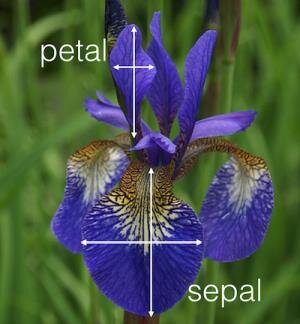

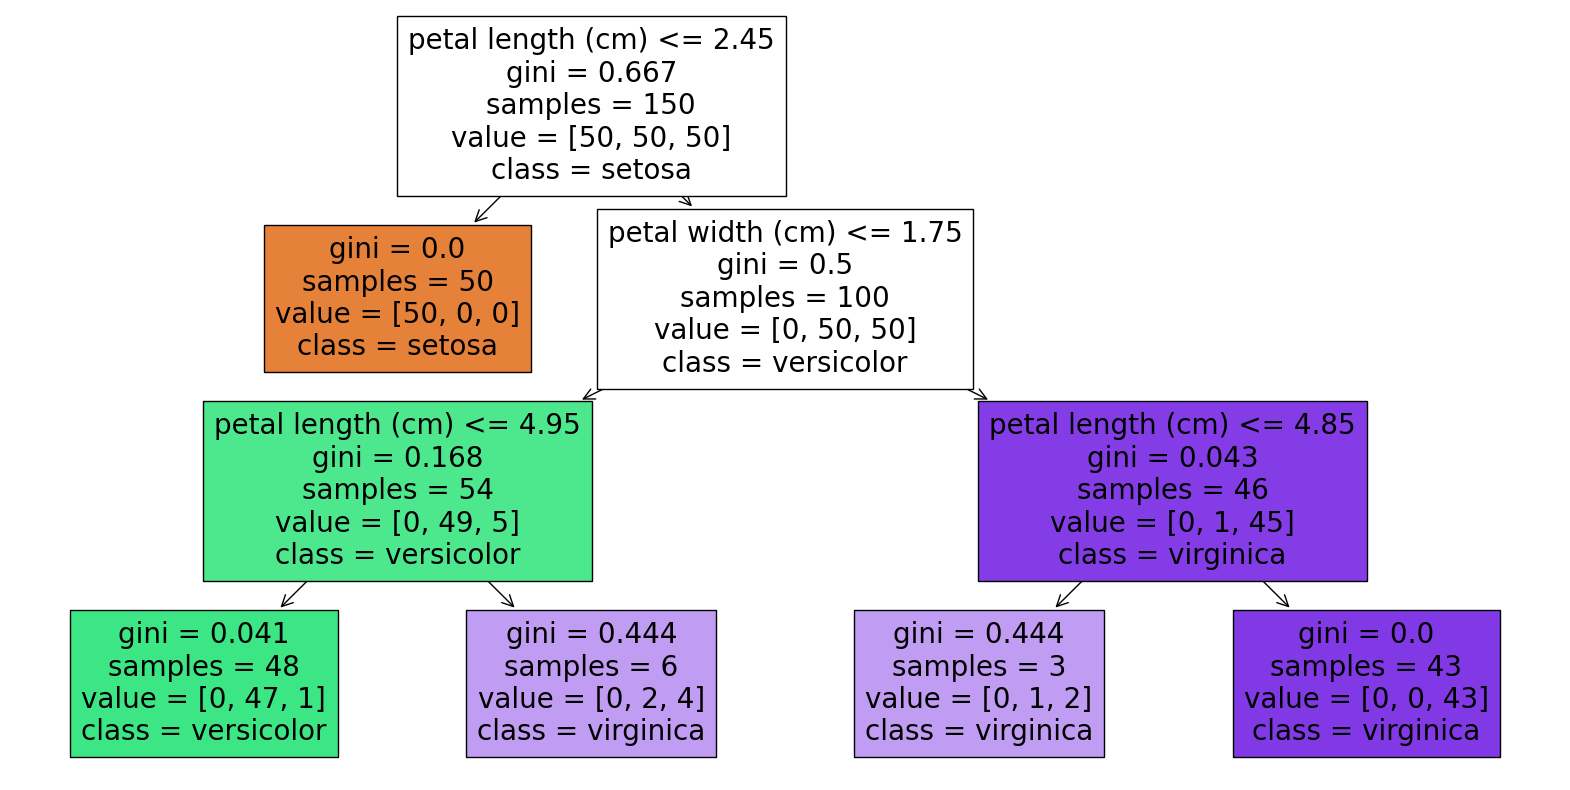

In [3]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt


# Create a decision tree classifier
clf = DecisionTreeClassifier(max_depth=3)  # Limiting depth for simplicity

# Train the model
clf.fit(X, y)

# Plot the decision tree
plt.figure(figsize=(20, 10))
plot_tree(clf,
          filled=True,
          feature_names=iris.feature_names,
          class_names=iris.target_names)
plt.show()

In the visualization, each node represents a decision based on one of the features, and the leaves represent the final predictions. This clear and straightforward visualization exemplifies why decision trees are considered white box models: you can trace the path from the root to any leaf to understand exactly how the model makes its predictions.

_Forgot what is Gini Index? don't worry, take a look at [this page](https://github.com/Naviden/ML-intro-with-Python/blob/main/Concepts/Other/Gini%20Index.md)_

### Black Box Models

**Definition**: Black box models refer to complex machine learning models whose internal decision-making processes are not readily understandable by humans. The "black box" metaphor indicates that it's difficult to see inside the model to understand how inputs are transformed into outputs.

**Characteristics**:
- **Complexity**: These models, including deep neural networks and ensemble methods like random forests and gradient boosting machines, can capture complex patterns and relationships in the data but at the cost of transparency.
- **Limited Interpretability**: The reasons behind their predictions are not easily discernible, making it challenging to explain their behavior in human-understandable terms.
- **High Performance**: Black box models often achieve higher accuracy and performance on complex tasks, such as image recognition, natural language processing, and predictive analytics, compared to simpler white box models.

**Challenges**:
- **Trust and Accountability**: The lack of transparency can lead to issues with trust, especially in critical applications like healthcare and criminal justice.
- **Ethical Concerns**: The inability to explain decisions may raise ethical concerns, particularly if the model's decisions impact people's lives significantly.

### MODEL USED

The model used is a sequential model, meaning the layers are stacked one after another in a linear way — input → hidden layers → output.

**🔷 Dense(64, activation='relu', input_shape=(X_train.shape[1], ))**
- This is the first hidden layer.
- Dense(64): It has 64 neurons, each connected to all inputs.
- activation='relu': Applies the ReLU activation function (Rectified Linear Unit), which outputs max(0, x) — helps model non-linear patterns.
- input_shape=(X_train.shape[1], ): Defines the number of input features (e.g., 4 for the Iris dataset: sepal length, sepal width, petal length, petal width).


**🔷 Dense(64, activation='relu')**
- The second hidden layer, again with 64 neurons and ReLU activation.
- Learns more complex patterns by combining outputs from the previous layer.


**🎯 Dense(3, activation='softmax')**
- The output layer.
- 3 neurons, one for each class (setosa, versicolor, virginica).
- activation='softmax': Converts the outputs into probabilities that sum to 1 — used for multiclass classification.


**✅ Summary of the Model's Purpose:**
- Takes in a flower's measurements (4 features),
- Passes them through 2 layers of 64 neurons using ReLU,
- Outputs probabilities for each of the 3 flower classes using softmax.

In [5]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Load the iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Preprocess the data
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# One-hot encode labels
y_onehot = to_categorical(y)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y_onehot,
                                                    test_size=0.2,
                                                    random_state=42)

# Define the model architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1], )),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=16, verbose=0)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {loss:.3f}, Test accuracy: {accuracy:.3f}')

2025-05-14 10:00:17.430938: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/filippo_pallucchini/Desktop/TEMP PYTHON/xai_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test loss: 0.013, Test accuracy: 1.000


_Forgot what is StandardScaler? don't worry, take a look at [this page](https://github.com/Naviden/ML-intro-with-Python/blob/main/Concepts/Preprocessing/StandardScaler.md)_

## Surrogate Models
A surrogate model is a simplified representation that approximates the behavior of a more complex, often opaque (black box) machine learning model. The primary goal of a surrogate model is to make the predictions and decision-making process of the black box model understandable to humans, without sacrificing too much accuracy. Surrogate models are especially useful in domains where interpretability and transparency are crucial, such as healthcare, finance, and criminal justice.

### How Surrogate Models Work

A surrogate model emulates the behavior of a black box model by learning the relationship between the input features and the output predictions of the black box. This process involves:

1. **Sampling and Predictions**: Generating or using an existing dataset where each instance is inputted into the black box model to get its predictions. This dataset, now enriched with predictions, serves as the training data for the surrogate model.

2. **Model Training**: Selecting a more interpretable model structure (e.g., decision tree, linear regression, or rule-based models) as the surrogate. This model is then trained on the dataset created in the first step, aiming to replicate the decision-making process of the black box model as closely as possible.

3. **Interpretation and Analysis**: Once trained, the surrogate model can be analyzed using various interpretability techniques. For example, decision trees can be visualized, and the importance of different features can be extracted in linear models. This analysis provides insights into how the original black box model makes its decisions.

### Advantages of Surrogate Models

- **Transparency**: They offer a way to understand complex models by approximating their functionality with simpler, interpretable models.
- **Flexibility**: Surrogate models can be applied to any black box model, regardless of its complexity, as they do not require changes to the original model.
- **Insightful**: They can provide valuable insights into feature importance and model behavior, aiding in model debugging, validation, and improvement.

### Limitations

- **Approximation Error**: Surrogate models are simplifications, which means they may not capture all the nuances of the black box model. The accuracy of interpretation depends on how well the surrogate model can approximate the original model.
- **Complexity Trade-off**: There's a balance to be struck between the interpretability of the surrogate model and its ability to accurately mimic the black box model. More interpretable models may offer less precise approximations.

In [6]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load the Boston housing dataset
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

# Train the black box model (Gradient Boosting Regressor)
black_box_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
black_box_model.fit(X_train, y_train)

# Use the black box model to make predictions on the test set
y_pred_black_box = black_box_model.predict(X_test)

# Use the black box model to label the entire dataset
y_labels_black_box = black_box_model.predict(X)

# Train the surrogate model (Linear Regression) on the entire dataset
# using the labels generated by the black box model
surrogate_model = LinearRegression()
surrogate_model.fit(X, y_labels_black_box)

# Use the surrogate model to make predictions on the test set
y_pred_surrogate = surrogate_model.predict(X_test)

# Calculate the fidelity of the surrogate model using the R² score
fidelity = r2_score(y_pred_black_box, y_pred_surrogate)
print(f"Fidelity of the Surrogate Model (R² Score): {fidelity:.4f}")

Fidelity of the Surrogate Model (R² Score): 0.7780


_Forgot what is Gradient Boosting Regressor? don't worry, take a look at [this page](https://github.com/Naviden/ML-intro-with-Python/blob/main/Concepts/ML%20Models/Regression/Gradient%20Boosting%20Regressor.md)_

INSTALL tensorflow and pandas
tensorflow:
- tensorflow==2.16.2
- tensorflow-io-gcs-filesystem==0.37.1

pandas:
- pandas==2.2.3